# Using Lysimeter Data in Drought-Response Experiments to Predict Performance Across Camelina Genotypes​
## William B, Nibir N, and Brianne S
### CMPT/PLSC 878​
## Training Script
### ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Step 1: Preliminaries

#### 1.1: Import libraries

In [84]:
! pip3 install torch torchvision torchaudio


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
# TODO

# 1.1 Import Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from collections import defaultdict

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut

# Deep Learning
import torch
import torch.nn as nn

# Custom Helper Functions
import helpers 

# Configuration
DATA_DIR = 'CamelinaMAGIC-Dataset-Complete'
EXPERIMENTS = [1, 2, 3] # We will process all three
RANDOMIZATION_FILE = os.path.join(DATA_DIR, 'CamelinaMAGIC-ALL-Randomization.xlsx')

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


#### 1.2: Define file paths

In [86]:
#TO DO

# 1.2 Data Loading and Processing

def load_and_process_all_experiments():
    all_X = []
    all_y = []
    metadata = [] # To track Genotype and Experiment for ranking later
    
    print("Loading data from Experiments:", EXPERIMENTS)
    
    for exp_num in EXPERIMENTS:
        print(f"  Processing Experiment {exp_num}...")
        
        # 1. Define Paths
        weight_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-WeightRaw.csv')
        transp_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-DailyTranspiration.csv')
        weather_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-WeatherStation.csv')
        
        # 2. Load Data using HELPERS.PY
        # Note: helpers returns long-format DataFrames
        try:
            df_weight = helpers.read_weight_csv(weight_file, RANDOMIZATION_FILE, exp_num)
            df_transp = helpers.read_transpiration_csv(transp_file, RANDOMIZATION_FILE, exp_num)
            df_weather = helpers.read_weather_station_csv(weather_file, exp_num)
        except Exception as e:
            print(f"    Skipping Exp {exp_num} due to error: {e}")
            continue

        # 3. Filter for DROUGHT Only 
        df_weight = df_weight[df_weight['Treatment'] == 'DR_100']
        df_transp = df_transp[df_transp['Treatment'] == 'DR_100']
        
        # 4. Merge Plant Data (Weight + Transpiration)
        # We merge on [Experiment, Genotype, Sample, Days]
        merged_plant = pd.merge(
            df_weight, 
            df_transp[['Days', 'Sample', 'Transpiration']], 
            on=['Days', 'Sample'], 
            how='inner'
        )

        # 5. Merge Weather Data for Normalization
        # helpers.read_weather_station_csv returns 'Days' and weather metrics.
        # We need to find the VPD column (it varies by file, e.g. "Cobble - VPD" vs "VPD")
        vpd_col = [c for c in df_weather.columns if 'VPD' in c]
        if vpd_col:
            vpd_col = vpd_col[0]
            df_weather = df_weather.rename(columns={vpd_col: 'VPD'})
            merged_full = pd.merge(merged_plant, df_weather[['Days', 'VPD']], on='Days', how='left')
            
            # Normalization
            merged_full['Transp_Norm'] = merged_full['Transpiration'] / merged_full['VPD']
        else:
            print(f"    Warning: No VPD found for Exp {exp_num}. Using raw Transpiration.")
            merged_full['Transp_Norm'] = merged_full['Transpiration']
            
        # 6. Smooth Data (Rolling Average)
        # Group by Sample to ensure we don't smooth across different plants
        cols_to_smooth = ['Weight', 'Transpiration', 'Transp_Norm']
        merged_full[cols_to_smooth] = merged_full.groupby('Sample')[cols_to_smooth].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )

        # 7. Extract Sequences (Features) and Targets (Slopes)
        INPUT_WINDOW = range(15, 26)   # Days 21-25 
        RECOVERY_WINDOW = range(36, 41) # Days 36-40 (Normal watering which will give)
        
        unique_samples = merged_full['Sample'].unique()
        
        for sample in unique_samples:
            sample_data = merged_full[merged_full['Sample'] == sample].sort_values('Days')
            
            # Extract Input X
            input_slice = sample_data[sample_data['Days'].isin(INPUT_WINDOW)]
            if len(input_slice) < 11: continue # Ensure complete data
            
            # Features: Weight, Transpiration, Transp_Norm
            features = input_slice[['Weight', 'Transpiration', 'Transp_Norm']].values
            
            # Extract Target y (Recovery Slope s3)
            recovery_slice = sample_data[sample_data['Days'].isin(RECOVERY_WINDOW)]
            if len(recovery_slice) < 2: continue
            
            # Calculate slope s3 (Weight gain during recovery)
            slope, _, _, _, _ = linregress(recovery_slice['Days'], recovery_slice['Transpiration'])
            
            all_X.append(features)
            all_y.append(slope)
            
            # Save metadata for ranking
            metadata.append({
                'Sample': sample,
                'Genotype': sample_data['Genotype'].iloc[0],
                'Experiment': exp_num
            })

    return np.array(all_X), np.array(all_y), pd.DataFrame(metadata)

# Execute Loading
X_all, y_all, meta_df = load_and_process_all_experiments()
print(f"\nFinal Dataset Created.")
print(f"  Features Shape (X): {X_all.shape} (Samples, TimeSteps, Features)")
print(f"  Targets Shape (y): {y_all.shape}")
print(f"  Genotypes Tracked: {meta_df['Genotype'].nunique()}")

Loading data from Experiments: [1, 2, 3]
  Processing Experiment 1...


h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()
h:\878Project\CMPT-878-Project\helpers.py:685: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


  Processing Experiment 2...


h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()
h:\878Project\CMPT-878-Project\helpers.py:685: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


  Processing Experiment 3...


h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()
h:\878Project\CMPT-878-Project\helpers.py:685: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()



Final Dataset Created.
  Features Shape (X): (75, 11, 3) (Samples, TimeSteps, Features)
  Targets Shape (y): (75,)
  Genotypes Tracked: 16


#### 1.3: Instantiate ML models

In [87]:
# TODO: First Model and its tunable parameters

# 1.3 Model Definitions

# LSTM Model Definition
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, output_dim=1, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm_out, _ = self.lstm(x) 
        # Take the output of the last time step
        last_out = lstm_out[:, -1, :]
        out = self.fc(last_out)
        return out

In [88]:
# TODO: Second Model and its tunable parameters



In [89]:
# TODO: Third Model and its tunable parameters



### Step 2: Train Models

#### 2.1: First Model

Implementation Notes: We should try round-robin testing! Since for each genotype we only have 4-5 samples, we need a training methodology that excels with small datasets.

You may need to define a file structure for storing models. I don't think they NEED to be saved, but it depends on how long it takes to train. It may be that this script will train models if there arent already saved models, but if there is, it simply skips training and only validates and reports metrics. This could save time when testing.

Round-robin: we have N samples. This means we train each model N different times, where we train it on N-1 samples and then validate on the single held-out sample. This cycles through so each sample will be the test set at least once.

In [90]:
# TODO
# 2.1 Round Robin Training Loop

# Storage for results
results_log = {
    'Linear Regression': {'true': [], 'pred': [], 'meta': []},
    'Random Forest': {'true': [], 'pred': [], 'meta': []},
    'LSTM': {'true': [], 'pred': [], 'meta': []}
}

loo = LeaveOneOut()
n_samples = len(X_all)

print(f"Starting Round-Robin (LOOCV) on {n_samples} samples...")

for i, (train_idx, test_idx) in enumerate(loo.split(X_all)):
    if i % 10 == 0: print(f"  Fold {i}/{n_samples}...")
    
    # 1. Split Data
    X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    sample_meta = meta_df.iloc[test_idx].to_dict('records')[0]
    
    # 2. Normalize Data (Fit on Train, Transform Test)
    # Flatten time series for scaling: (N, 11, 3) -> (N*11, 3)
    N_train, T, F = X_train_raw.shape
    
    scaler = StandardScaler()
    X_train_flat = X_train_raw.reshape(-1, F)
    scaler.fit(X_train_flat) # Fit ONLY on training data
    
    # Transform Train
    X_train_scaled = scaler.transform(X_train_flat).reshape(N_train, T, F)
    # Transform Test
    X_test_scaled = scaler.transform(X_test_raw.reshape(-1, F)).reshape(1, T, F)
    
    # Flatten for non-deep learning models
    X_train_flat_model = X_train_scaled.reshape(N_train, -1)
    X_test_flat_model = X_test_scaled.reshape(1, -1)
    
    # --- MODEL 1: Linear Regression (Re-instantiated) ---
    lr = LinearRegression()
    lr.fit(X_train_flat_model, y_train)
    lr_pred = lr.predict(X_test_flat_model)[0]
    
    results_log['Linear Regression']['true'].append(y_test[0])
    results_log['Linear Regression']['pred'].append(lr_pred)
    results_log['Linear Regression']['meta'].append(sample_meta)

    # --- MODEL 2: Random Forest (Re-instantiated) ---
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train_flat_model, y_train)
    rf_pred = rf.predict(X_test_flat_model)[0]
    
    results_log['Random Forest']['true'].append(y_test[0])
    results_log['Random Forest']['pred'].append(rf_pred)
    results_log['Random Forest']['meta'].append(sample_meta)

    # --- MODEL 3: LSTM (Re-instantiated) ---
    # Prepare Tensors
    X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_torch = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
    
    lstm = LSTMRegressor(input_dim=3, hidden_dim=16, num_layers=1)
    optimizer = torch.optim.Adam(lstm.parameters(), lr=0.01, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    lstm.train()
    for epoch in range(2000):
        optimizer.zero_grad()
        out = lstm(X_train_torch)
        loss = criterion(out, y_train_torch)
        loss.backward()
        optimizer.step()
        
    lstm.eval()
    with torch.no_grad():
        lstm_pred = lstm(X_test_torch).item()
        
    results_log['LSTM']['true'].append(y_test[0])
    results_log['LSTM']['pred'].append(lstm_pred)
    results_log['LSTM']['meta'].append(sample_meta)

print("Training Complete.")


Starting Round-Robin (LOOCV) on 75 samples...
  Fold 0/75...
  Fold 10/75...
  Fold 20/75...
  Fold 30/75...
  Fold 40/75...
  Fold 50/75...
  Fold 60/75...
  Fold 70/75...
Training Complete.


#### 2.2: Second Model

In [91]:
# TODO


#### 2.3: Third Model

In [92]:
# TODO


### Step 3: Validation and Performance Reporting

Implementation Notes: This should be where each model tries predicting for one single sample each (if using round-robin) and the performance for each instance of model (each round) is reported clearly and stored for step 4.

In [93]:
!pip install tabulate


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



=== Model Performance Summary ===
| Model             |     R2 |   RMSE |   MAE |
|:------------------|-------:|-------:|------:|
| Linear Regression | 0.5868 | 2.9034 | 2.229 |
| Random Forest     | 0.533  | 3.0866 | 2.44  |
| LSTM              | 0.3032 | 3.7702 | 2.977 |


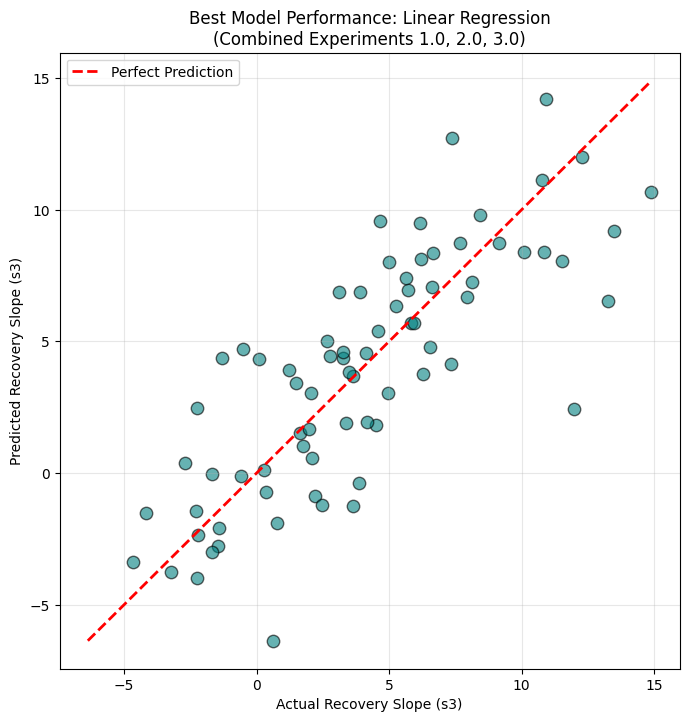

In [94]:
# TODO

# 3.1 Performance Evaluation

metric_summary = []

for model_name, data in results_log.items():
    y_true = np.array(data['true'])
    y_pred = np.array(data['pred'])
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    metric_summary.append({
        'Model': model_name,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })

metrics_df = pd.DataFrame(metric_summary)
print("\n=== Model Performance Summary ===")
print(metrics_df.round(4).to_markdown(index=False))

# --- Visualization: Predicted vs Actual ---
best_model_name = metrics_df.loc[metrics_df['R2'].idxmax()]['Model']
best_data = results_log[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(best_data['true'], best_data['pred'], alpha=0.6, edgecolors='k', s=80, color='teal')

# Perfect fit line
min_val = min(min(best_data['true']), min(best_data['pred']))
max_val = max(max(best_data['true']), max(best_data['pred']))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Recovery Slope (s3)')
plt.ylabel('Predicted Recovery Slope (s3)')
plt.title(f'Best Model Performance: {best_model_name}\n(Combined Experiments 1.0, 2.0, 3.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 3.1: First Model Validation and Performance

In [95]:
# TODO



#### 3.2: Second Model Validation and Performance

In [96]:
# TODO



#### 3.3: Third Model Validation and Performance

In [97]:
# TODO


### Step 4: Overall Performance Report

Implementation Notes: This should be a report of each model's performance. If using round-robin, the mean accuracy across all instances of each model should be used to show the model's general performance.

We should rank the model's performances, and visualize things like error rate and gradient, and demonstrate clear understanding of each ML model's performances and why one model did better than another. This should give us additional information on the nature of the problem, which is the connection between early-stage input (early plant drought behaviour) to end (plant drought performance).

C:\Users\darkp\AppData\Local\Temp\ipykernel_16948\1271661646.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Score', data=r2_data, palette='viridis')


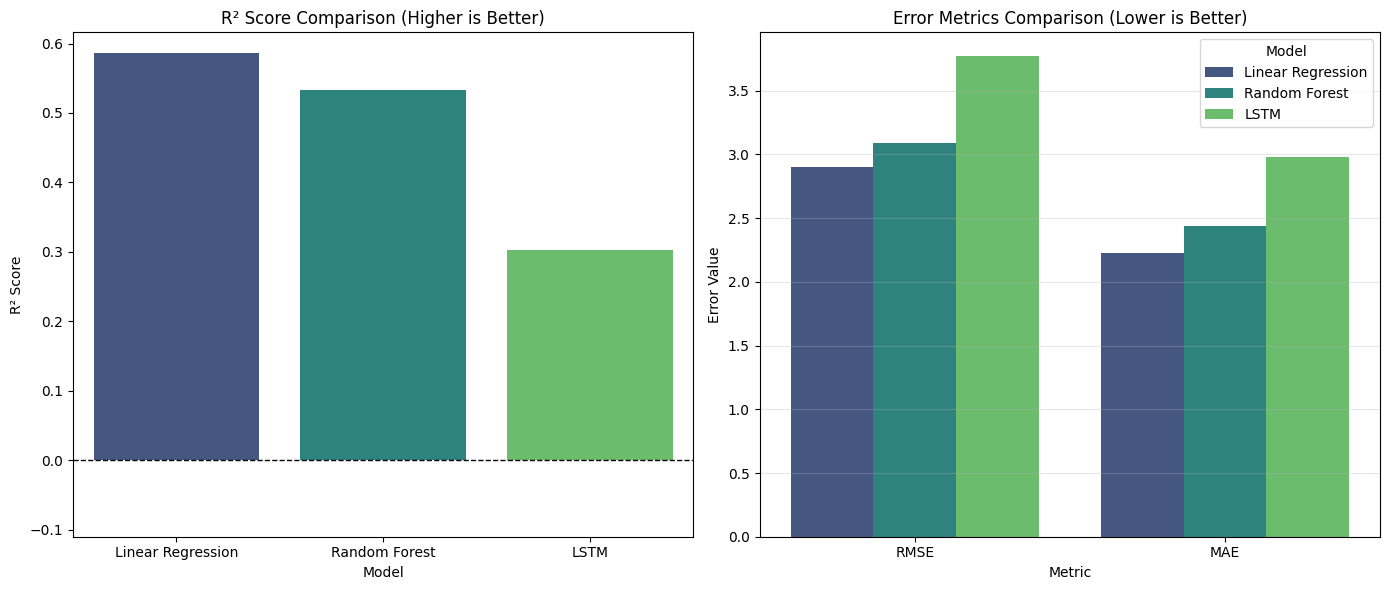

In [98]:
# TODO: Report and compare the performance of all three models
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reshape data for plotting
# We 'melt' the DataFrame to make it compatible with seaborn's hue/grouping
plot_df = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 2. Setup the figure
plt.figure(figsize=(14, 6))

# --- Subplot 1: R2 Score (Higher is Better) ---
plt.subplot(1, 2, 1)
# Filter for just R2
r2_data = plot_df[plot_df['Metric'] == 'R2']
sns.barplot(x='Model', y='Score', data=r2_data, palette='viridis')

plt.title('R² Score Comparison (Higher is Better)')
plt.ylabel('R² Score')
plt.axhline(0, color='k', linewidth=1, linestyle='--') # Zero line for reference
# Adjust y-limit to handle your negative LSTM score gracefully if needed
bottom_lim = r2_data['Score'].min()
plt.ylim(bottom=min(bottom_lim, -0.1) * 1.1) 

# --- Subplot 2: Error Metrics (Lower is Better) ---
plt.subplot(1, 2, 2)
# Filter for RMSE and MAE
error_data = plot_df[plot_df['Metric'].isin(['RMSE', 'MAE'])]
sns.barplot(x='Metric', y='Score', hue='Model', data=error_data, palette='viridis')

plt.title('Error Metrics Comparison (Lower is Better)')
plt.ylabel('Error Value')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Genotype Rankings

Here I just used the formula for drought score from the report to calculate the scores for each genotype and rank them

re-calculating s1 (baseline) and s2 (drought onset) slopes from raw data...


h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()
h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()
h:\878Project\CMPT-878-Project\helpers.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weight.resample(resample_freq, label="left", closed="left").mean()



=== Top 5 Drought Resilient Genotypes (Based on Model Score) ===
| Genotype   |   Drought_Score |
|:-----------|----------------:|
| Hoga       |        -10.6262 |
| Jasper     |        -31.5015 |
| CAM236     |        -38.8062 |
| TMP23992   |        -41.669  |
| TMP23990   |        -70.8491 |


C:\Users\darkp\AppData\Local\Temp\ipykernel_16948\3399109230.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drought_Score', y='Genotype', data=genotype_ranks, palette='magma')


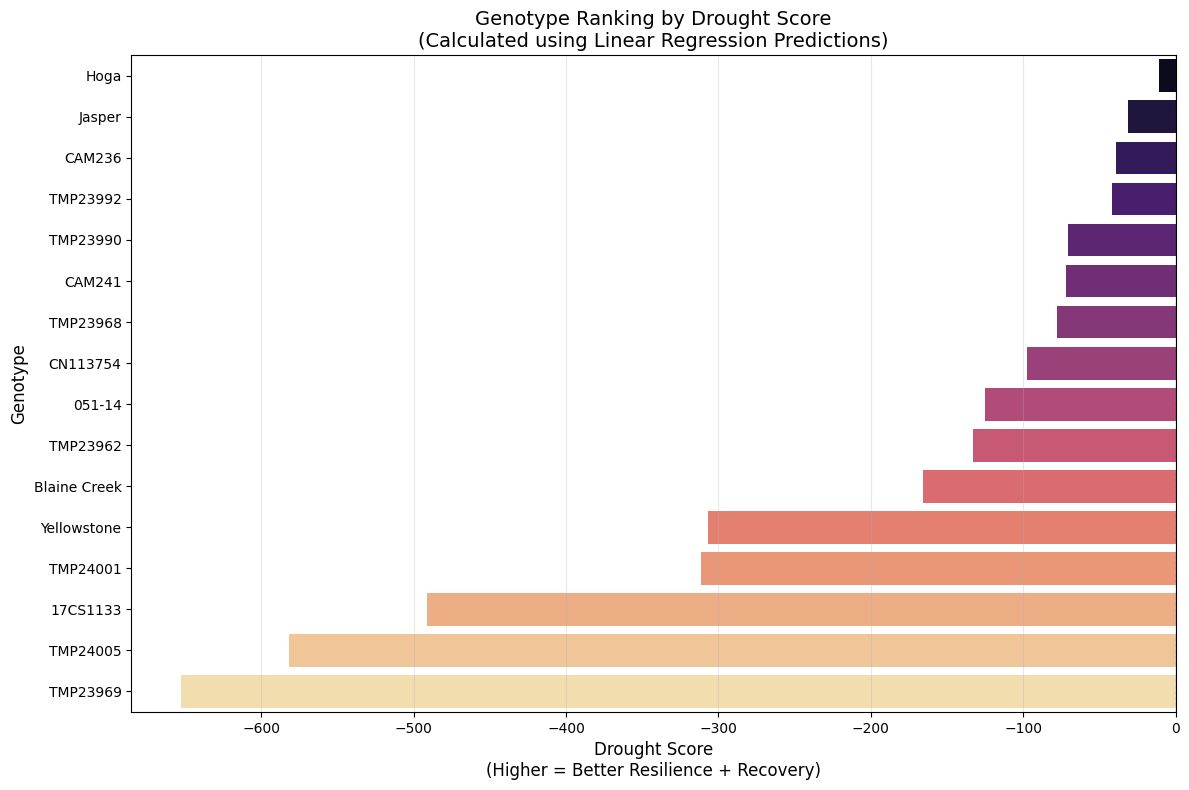

In [ ]:
# --- Step 5: Drought Score Calculation & Genotype Ranking ---

def calculate_drought_scores(best_model_name, results_log):
    print("re-calculating s1 (baseline) and s2 (drought onset) slopes from raw data...")
    
    # 1. Extract Predictions from Best Model
    best_results = results_log[best_model_name]
    score_df = pd.DataFrame(best_results['meta'])
    score_df['s3_pred'] = best_results['pred'] # Predicted s3 from model
    
    # 2. Dictionary to store s1 and s2 for mapping
    slope_data = {}
    
    # 3. Reload Data to get s1 and s2 (since we didn't save them earlier)
    # We iterate through experiments again to calculate these specific slopes
    for exp_num in EXPERIMENTS:
        weight_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-WeightRaw.csv')
        try:
            # Load Weight Data
            df_weight = helpers.read_weight_csv(weight_file, RANDOMIZATION_FILE, exp_num)
            df_weight = df_weight[df_weight['Treatment'] == 'DR_100'] # Drought only
            
            # Windows for s1 and s2
            BASELINE_WINDOW = range(1, 21)   # Days 1-20
            DROUGHT_WINDOW = range(21, 26)   # Days 21-25
            
            for sample in df_weight['Sample'].unique():
                sample_data = df_weight[df_weight['Sample'] == sample].sort_values('Days')
                
                # Calculate s1 (Baseline Slope)
                base_slice = sample_data[sample_data['Days'].isin(BASELINE_WINDOW)]
                if len(base_slice) > 1:
                    s1, _, _, _, _ = linregress(base_slice['Days'], base_slice['Weight'])
                else:
                    s1 = np.nan
                    
                # Calculate s2 (Drought Onset Slope)
                drought_slice = sample_data[sample_data['Days'].isin(DROUGHT_WINDOW)]
                if len(drought_slice) > 1:
                    s2, _, _, _, _ = linregress(drought_slice['Days'], drought_slice['Weight'])
                else:
                    s2 = np.nan
                
                slope_data[sample] = {'s1': s1, 's2': s2}
                
        except Exception as e:
            print(f"Skipping Exp {exp_num} for slope calc: {e}")

    # 4. Map s1 and s2 to the Score DataFrame
    score_df['s1'] = score_df['Sample'].map(lambda x: slope_data.get(x, {}).get('s1', np.nan))
    score_df['s2'] = score_df['Sample'].map(lambda x: slope_data.get(x, {}).get('s2', np.nan))
    
    # Drop samples where slopes couldn't be calculated
    score_df = score_df.dropna(subset=['s1', 's2', 's3_pred'])
    
    # 5. Calculate Drought Score
    # Formula: Score = w1*(-s2/s1) + w2*(s3/s1)
    # User specified w1=1, w2=1
    
    w1 = 1.0
    w2 = 1.0
    
    # We use abs(s1) or ensure s1 is positive to avoid sign flipping issues if baseline was noisy
    # Assuming baseline growth is generally positive.
    score_df['Drought_Score'] = (w1 * (-score_df['s2'] / score_df['s1'])) + \
                                (w2 * (score_df['s3_pred'] / score_df['s1']))
    
    return score_df

# --- Execute and Plot ---

# Calculate Scores
final_scores_df = calculate_drought_scores(best_model_name, results_log)

# Rank Genotypes (Mean Score)
genotype_ranks = final_scores_df.groupby('Genotype')['Drought_Score'].mean().sort_values(ascending=False).reset_index()

print("\n=== Top 5 Drought Resilient Genotypes (Based on Model Score) ===")
print(genotype_ranks.head(5).to_markdown(index=False))

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Drought_Score', y='Genotype', data=genotype_ranks, palette='magma')

plt.title(f'Genotype Ranking by Drought Score\n(Calculated using {best_model_name} Predictions)', fontsize=14)
plt.xlabel('Drought Score\n(Higher = Better Resilience + Recovery)', fontsize=12)
plt.ylabel('Genotype', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
# # 4.1 Genotype Ranking (Using Best Model)

# print(f"Generating Ranking using predictions from: {best_model_name}")

# # Create a DataFrame from the results of the best model
# ranking_df = pd.DataFrame(results_log[best_model_name]['meta'])
# ranking_df['Predicted_s3'] = results_log[best_model_name]['pred']
# ranking_df['Actual_s3'] = results_log[best_model_name]['true']

# # Group by Genotype and calculate mean predicted recovery slope
# # Higher slope = Faster weight gain during recovery = Better Drought Tolerance
# genotype_ranking = ranking_df.groupby('Genotype')['Predicted_s3'].mean().sort_values(ascending=False).reset_index()

# # Add a ranking column
# genotype_ranking['Rank'] = genotype_ranking.index + 1

# print("\n=== Genotype Drought Tolerance Ranking (Predicted) ===")
# print(genotype_ranking.to_markdown(index=False))

# # Visualization of Ranking
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Predicted_s3', y='Genotype', data=genotype_ranking, palette='viridis')
# plt.xlabel('Mean Predicted Recovery Slope (s3)')
# plt.title(f'Genotype Ranking by Predicted Recovery Speed\n(Model: {best_model_name})')
# plt.grid(axis='x', alpha=0.3)
# plt.show()